# Spike Analysis Tutorial: From Raw Data to PSTH/Raster Plots

This notebook demonstrates the core workflow for analyzing spike-sorted electrophysiology data using the `spike_analysis_tools` library. Steps:

1. **Load spike data** from Kilosort output
2. **Load behavioral data** (stimulus timing)
3. **Filter units** by firing rate
4. **Filter trials** by stimulus type
5. **Align spikes** to stimulus onset
6. **Compute statistics** (baseline vs response)
7. **Plot** PSTH and raster for a single unit

## Setup: Import libraries and add spike_analysis_tools to path

In [25]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Add spike_analysis_tools to path
sys.path.insert(0, str(Path.home() / 'python_tools' / 'spike_analysis_tools'))
import spike_analysis_tools as spike_tools

# Use dark background style
plt.style.use('dark_background')

## Define paths and parameters

**Update these paths to match your data:**

In [26]:
# Recording information
recording = 'Pancake_20250306'  # Undecorated basename for this recording
subject = 'Pancake'
area = 'R_PFC'
behavior_ts = '2025-03-06_18-36-55'  # Behavior timestamp

# File paths
data_path = Path(f'/goedel_store01/rmorrill/SpikeGLX_data/{recording}_g0')
spikesort_path = data_path / f'{recording}_g0_imec0' / 'kilosort4_SI' / 'run_sorter' / 'sorter_output'

# Analysis parameters
time_win = [-0.2, 0.5]      # Time window around stimulus onset (seconds) - for data return
twin_BL = [-0.2, 0]         # Baseline window for statistics
twin_resp = [0.1, 0.3]      # Response window for statistics
binwidth = 0.02             # PSTH bin width (20 ms)
min_FR = 0.1                # Minimum firing rate threshold (spikes/sec)

## Step 1: Load spike data from Kilosort output

Kilosort produces:
- `spike_times.npy` — timestamp of each spike (in sec)
- `spike_clusters.npy` — cluster ID for each spike
- `cluster_group.tsv` — shows quality labels for each cluster ('good', 'mua', 'noise')

We load only 'good' units (these are KS4 automatically curated single units).

In [27]:
# Load spike times (st), spike clusters (sc), and cluster groups (cg)
st, sc, cg = spike_tools.get_spikes(spikesort_path, label='good')

print(f"Loaded {len(st)} spikes from {len(cg)} good units")
print(f"Cluster IDs: {cg['cluster_id'].to_numpy()}")

get_spikes: no unit filter provided, returning label filter for  good clusts
found 4593152 spikes
Loaded 4593152 spikes from 389 good units
Cluster IDs: [  7   8  10  12  14  17  19  22  23  28  33  35  39  40  41  43  44  49
  50  52  53  55  57  66  67  68  72  74  75  78  80  81  82  83  84  87
  88  89  90  91  92  93  95  96  98 100 104 105 108 110 111 112 115 119
 120 123 125 126 127 128 129 132 134 135 143 144 145 147 150 153 155 159
 160 161 162 165 166 167 168 174 175 177 181 182 183 185 186 189 190 191
 192 195 197 198 199 200 202 205 207 208 209 211 213 215 216 219 220 222
 223 224 226 227 230 231 233 234 235 237 238 239 240 241 242 243 245 246
 247 251 252 253 256 259 260 261 262 267 268 271 273 275 278 279 281 282
 284 285 287 289 290 292 296 297 298 299 301 302 309 310 311 316 319 322
 325 326 327 328 329 331 333 334 336 337 338 341 342 343 345 347 349 352
 354 356 361 363 364 366 368 369 372 374 380 381 383 384 386 390 391 392
 395 403 405 408 409 412 414 415 419 421 422

## Step 2: Load stimulus data

Stimulus sequence data is stored in behavior_py folder and stimulus timing is stored in triggers.npz:
- **Stimulus onset times** — when each image appeared
- **Stimulus offset times** — when each image disappeared
- **Image sequence** — which images were shown in which order
- **Experiment start/end** — recording start/stop times for filtering overall firing rate of units

In [28]:
# Get stimulus onset and offset times (in seconds)
start_times, end_times = spike_tools.get_stim_times(data_path, behavior_ts)
n_trials = len(start_times)
print(f"Found {n_trials} stimulus presentations")

# Get experiment start and end times
# useful for filtering by minimum FR later on
expt_start, expt_end = spike_tools.get_expt_times(data_path, behavior_ts)
print(f"Experiment ran from {expt_start:.1f}s to {expt_end:.1f}s")

# Get the sequence of images presented
images_displayed = spike_tools.return_images_displayed(data_path, behavior_ts)
images_displayed_fnames = [Path(image).name for image in images_displayed]
print(f"\nFirst 10 images: {images_displayed_fnames[:10]}")

Found 943 stimulus presentations
Experiment ran from 2323.2s to 4914.8s

First 10 images: ['b1.png', 'b10.png', 'b11.png', 'b12.png', 'b13.png', 'b14.png', 'b15.png', 'b16.png', 'b17.png', 'b18.png']


## Step 3: Filter units by firing rate

We only analyze units with sufficient activity during the experiment.
Low firing rate units may be unstable or poorly isolated.

In [29]:
# Get all 'good' cluster IDs
good_clusts = cg['cluster_id'].to_numpy()

# Filter by firing rate during ***entire experiment period***
filt_clusts, fr_filt_clusts = spike_tools.filter_clusts_fr(
    good_clusts, 
    spikesort_path, 
    start_end_t=(expt_start, expt_end), 
    min_FR=min_FR
)

print(f"FR filter of {min_FR} spks/sec returned {len(filt_clusts)} of {len(good_clusts)} units")
## Uncomment to show FRs for all units
# for clust, fr in zip(filt_clusts, fr_filt_clusts):
#     print(f"  Unit {clust}: {fr:.2f} spks/sec")

get_spikes: returning spikes in clusts [  7   8  10  12  14  17  19  22  23  28  33  35  39  40  41  43  44  49
  50  52  53  55  57  66  67  68  72  74  75  78  80  81  82  83  84  87
  88  89  90  91  92  93  95  96  98 100 104 105 108 110 111 112 115 119
 120 123 125 126 127 128 129 132 134 135 143 144 145 147 150 153 155 159
 160 161 162 165 166 167 168 174 175 177 181 182 183 185 186 189 190 191
 192 195 197 198 199 200 202 205 207 208 209 211 213 215 216 219 220 222
 223 224 226 227 230 231 233 234 235 237 238 239 240 241 242 243 245 246
 247 251 252 253 256 259 260 261 262 267 268 271 273 275 278 279 281 282
 284 285 287 289 290 292 296 297 298 299 301 302 309 310 311 316 319 322
 325 326 327 328 329 331 333 334 336 337 338 341 342 343 345 347 349 352
 354 356 361 363 364 366 368 369 372 374 380 381 383 384 386 390 391 392
 395 403 405 408 409 412 414 415 419 421 422 424 425 426 428 430 431 432
 433 435 438 440 441 444 447 449 451 452 453 454 455 456 458 459 461 462
 464 466 470

## Step 4: Filter trials by stimulus type

Song et al. FOB stimulus set contains:
- **Marmoset faces** (m*.png)
- **Object faces** (u*.png)  
- **Body parts** (b*.png)

We create boolean filters to identify which trials showed which stimulus type.

In [ ]:
# Define stimulus patterns (try standard naming first)
stim_filt = (r'm\d+.png', r'u\d+.png', r'b\d+.png')
image_filters = spike_tools.filter_stim_sequence(data_path, behavior_ts, stim_filt, use_regex=True)

# if that didn't work, gather both BW and color variants - naming may have changed
if np.sum(image_filters) == 0:
    print('Using alternate filters (BW/color variants)')
    stim_filt_BW = (r'm\d+_cropped.png', r'u\d+_cropped.png', r'b\d+_cropped.png')
    image_filters_BW = spike_tools.filter_stim_sequence(data_path, behavior_ts, stim_filt_BW, use_regex=True)
    
    stim_filt_COL = (r'm\d+_color.png', r'u\d+_color.png', r'b\d+_color.png')
    image_filters_COL = spike_tools.filter_stim_sequence(data_path, behavior_ts, stim_filt_COL, use_regex=True)
    
    image_filters = image_filters_BW | image_filters_COL
    stim_filt = stim_filt_BW  # for labels

# image_filters shape: (n_stim_types, n_trials)
print(f"\nStimulus type counts:")
for i, pattern in enumerate(['Marm faces', 'Objects', 'Body parts']):
    n_trials_this_stim = np.sum(image_filters[i, :])
    print(f"  {pattern}: {n_trials_this_stim} trials")

filtering for m\d+.png, use regex: True
filtering for u\d+.png, use regex: True
filtering for b\d+.png, use regex: True

Stimulus type counts:
  Marm faces: 276 trials
  Objects: 285 trials
  Body parts: 304 trials


## Step 5: Select a unit and extract its spike train

Analyze the first unit that passed the firing rate filter.

In [31]:
# Select first unit for analysis
clust = int(filt_clusts[0]) # change here to analyze a different unit
spike_train = st[sc == clust]

print(f"Analyzing unit {clust}")
print(f"Total spikes: {len(spike_train)}")
print(f"Firing rate across recording: {fr_filt_clusts[0]:.2f} spks/sec")

Analyzing unit 7
Total spikes: 4235
Firing rate across recording: 1.04 spks/sec


## Step 6: Align spikes to face stimulus onset

We'll focus on **face trials** (stimulus type index 0).

The `return_spike_array` function:
- Takes spike times and trigger times
- Returns a list of arrays, one per trial
- Each array contains spike times relative to stimulus onset

In [32]:
# Select marmoset face trials (index 0 in image_filters)
face_trial_filter = image_filters[0, :].astype(bool)

# Align spikes to stimulus onset for face trials
spike_array = spike_tools.return_spike_array(
    spike_train, 
    start_times, 
    time_win, 
    trial_filt=face_trial_filter
)

n_face_trials = len(spike_array)
print(f"\nExample: Trial 0 spikes relative to onset: {spike_array[0]}")

returning spikes for 276 trs

Example: Trial 0 spikes relative to onset: [0.18516288 0.48139621]


## Step 7: Compute PSTH (Peri-Stimulus Time Histogram)

The PSTH shows average firing rate over time across all trials.
- Bin spikes into time bins
- Average across trials
- Convert to firing rate (spikes/sec)

In [33]:
# Compute PSTH
psth_mu, psth_std, psth_sem, psth_t = spike_tools.return_PSTH(
    spike_array, 
    time_win[0], 
    time_win[1], 
    binwidth=binwidth
)

# Apply smoothing for visualization
psth_mu_sm = spike_tools.smooth_signal(psth_mu)
psth_sem_sm = spike_tools.smooth_signal(psth_sem)

print(f"PSTH computed with {len(psth_t)} time bins")
print(f"Peak firing rate: {np.max(psth_mu_sm):.1f} spks/sec")

PSTH computed with 35 time bins
Peak firing rate: 1.3 spks/sec


## Step 8: Test for significant response

Compare firing rate in baseline window vs. response window using a t-test. Windows are set at the top of this notebook.
- **Baseline** (twin_BL): activity before stimulus
- **Response** (twin_resp): activity after stimulus onset

In [34]:
# Statistical test: baseline vs response
res = spike_tools.sig_resp_calc(spike_array, twin_BL, twin_resp, test='ttest')

pval = res.pvalue
alpha_thresh = 0.05
is_sig = pval < alpha_thresh

print(f"Significance test:")
print(f"  p-value = {pval:.5f}")
print(f"  Significant response: {is_sig} (alpha = {alpha_thresh})")

Significance test:
  p-value = 0.76813
  Significant response: False (alpha = 0.05)


## Step 9: Plot PSTH and Raster

**Raster plot (top):** Each row is one trial, dots show spike times  
**PSTH (bottom):** Average firing rate across trials with SEM shading  

Vertical line at t=0 marks stimulus onset.

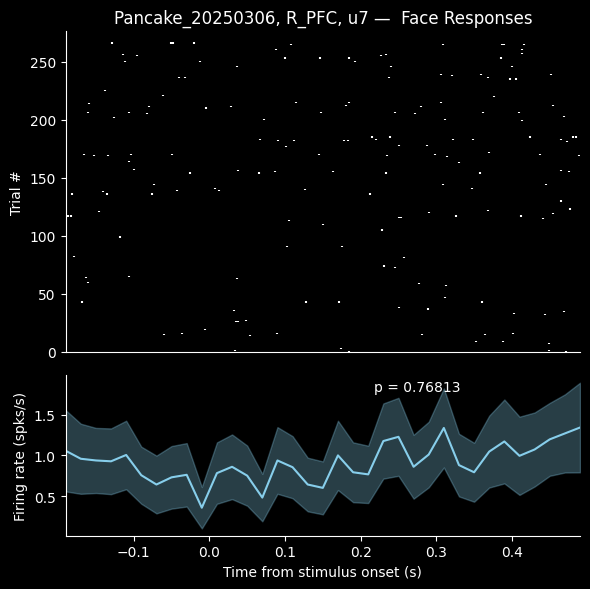

In [35]:
# Create figure with two subplots (raster on top, PSTH below)
fig = plt.figure(figsize=(6, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])

# --- Raster plot ---
ax_rast = fig.add_subplot(gs[0])
spike_tools.plot_raster(
    spike_array, 
    time_win[0], 
    time_win[1], 
    col='white', 
    ax=ax_rast, 
    xlabel_off=True
)
ax_rast.set_title(f'{recording}, {area}, u{clust} —  Face Responses', fontsize=12)
ax_rast.set_ylabel('Trial #')

# --- PSTH plot ---
ax_psth = fig.add_subplot(gs[1])
spike_tools.plot_PSTH(
    psth_mu_sm, 
    psth_sem_sm, 
    psth_t, 
    col='skyblue', 
    ax=ax_psth
)
ax_psth.set_xlabel('Time from stimulus onset (s)')
ax_psth.set_ylabel('Firing rate (spks/s)')

# Add p-value annotation
xL = ax_psth.get_xlim()
yL = ax_psth.get_ylim()
xloc_text = np.diff(xL) * 0.6 + xL[0]
yloc_text = np.diff(yL) * 0.9 + yL[0]
fontwt = 'extra bold' if is_sig else 'regular'
ax_psth.text(xloc_text, yloc_text, f'p = {pval:.5f}', fontsize=10, fontweight=fontwt)

plt.tight_layout()
plt.show()